In [1]:
from codecs import ignore_errors
from pathlib import Path
from pydoc import describe

import numpy.random
import pandas as pd
import tarfile
import urllib.request

from IPython.core.pylabtools import figsize
from sklearn.pipeline import make_pipeline


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter='data')
    return pd.read_csv(Path("datasets/housing/housing.csv"))
housing_full = load_housing_data()


In [2]:
housing_full.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


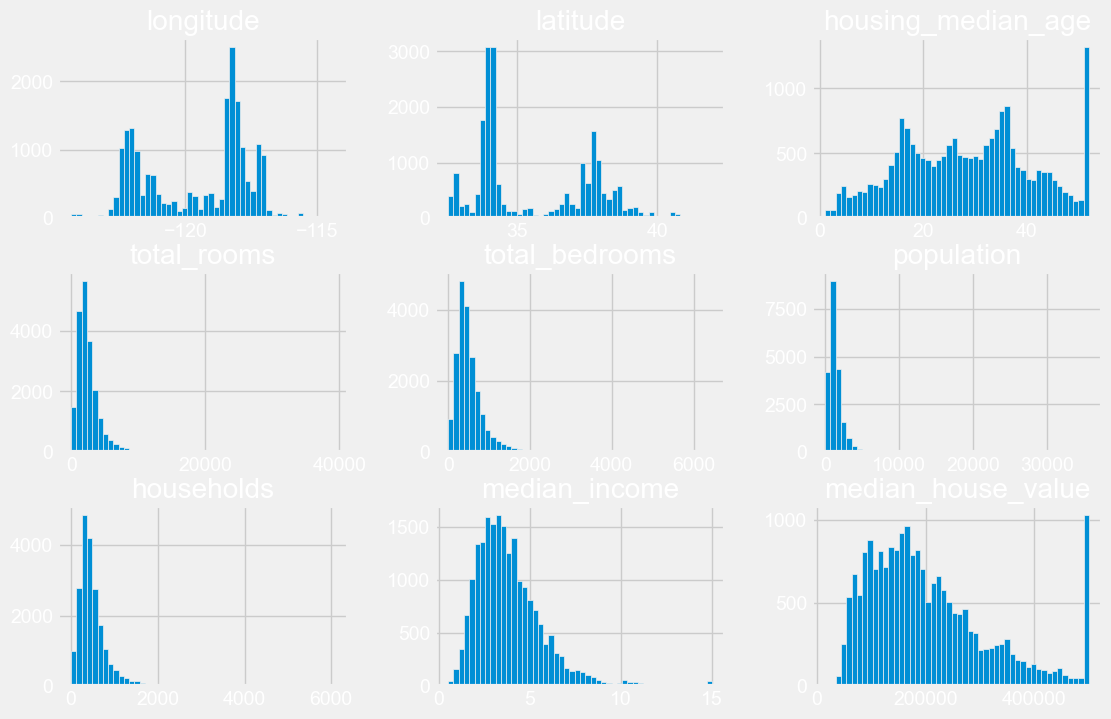

In [6]:
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

housing_full.hist(bins=50, figsize=(12,8))
plt.show()

In [7]:
import numpy as np

rng = np.random.default_rng(seed=42)


def train_test_split(data,test_ratio,rng):
    shuffled_indexes = rng.permutation(len(data))
    test_size = int(len(data) * test_ratio) #1000 * 0.2 = 200
    test_indexes = shuffled_indexes[:test_size]
    train_indexes = shuffled_indexes[test_size:]
    return data.iloc[train_indexes], data.iloc[test_indexes]

train, test = train_test_split(housing_full,test_ratio=0.2 , rng=rng)
print(f"train shape {train.shape} , test shape {test.shape}")

train shape (16512, 10) , test shape (4128, 10)


In [8]:
train["households"].head()

18731    352.0
3002     286.0
19844    939.0
4939     532.0
1674     402.0
Name: households, dtype: float64

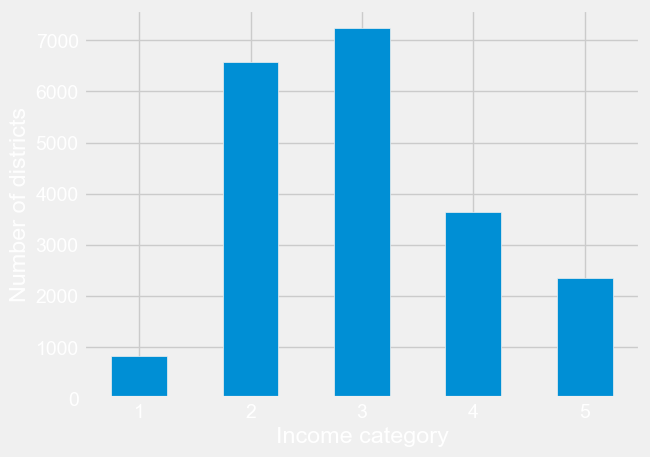

In [9]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"], bins = [0,1.5,3.0,4.5,6.0,np.inf], labels = [1,2,3,4,5])

cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0,grid = True )
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [10]:
from zlib import crc32

def is_id_in_test_set(identifier , test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data,test_ratio ,id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_ : is_id_in_test_set(id_,test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]


housing_with_id = housing_full.reset_index()
train, test= split_data_with_id_hash(housing_with_id,0.2,"index")
print(f"train shape {train.shape} , test shape {test.shape}")


train shape (16512, 12) , test shape (4128, 12)


In [11]:
from sklearn.model_selection import train_test_split

train,test = train_test_split(housing_full,test_size = 0.2,random_state=42,stratify=housing_full["income_cat"])
print(f"train shape {train.shape} , test shape {test.shape}")


train shape (16512, 11) , test shape (4128, 11)


In [12]:
train["income_cat"].value_counts() / len(train)
test["income_cat"].value_counts() / len(test)


income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [13]:
for set_ in (test,train):
    set_.drop("income_cat" , axis =1, inplace = True)

In [14]:
h = train.copy()

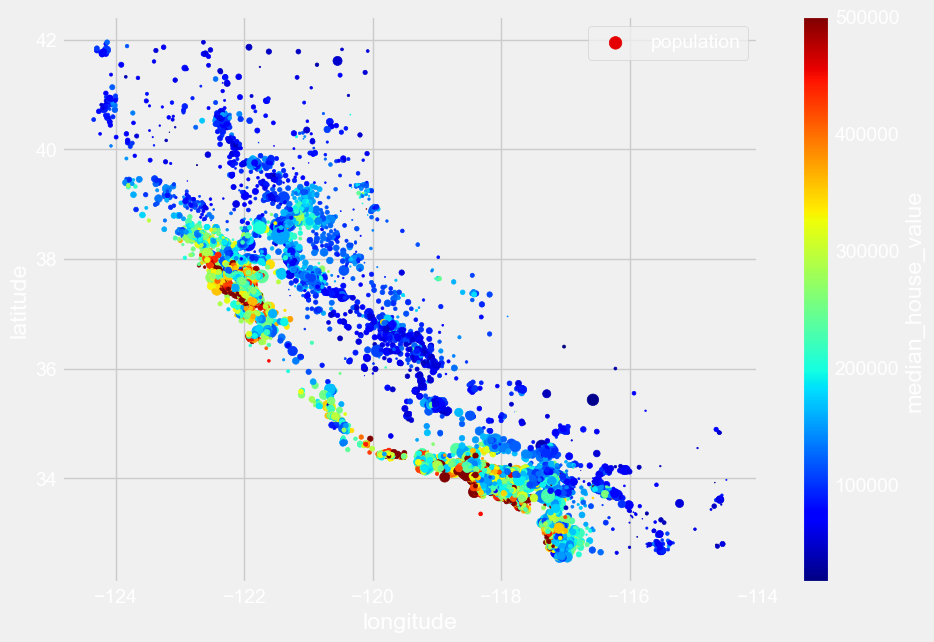

In [15]:
h.plot(kind = "scatter" , x = "longitude" , y = "latitude", grid= True, s = h["population"] / 100 , label = "population", c = "median_house_value", cmap="jet" , colorbar = True, legend = True, sharex = False, figsize=(10,7))
plt.show()

In [16]:
corr_matrix = h.corr(numeric_only = True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [17]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value" , "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(h[attributes], figsize=(12,8))
plt.show()

KeyboardInterrupt: 

In [ ]:
plt.scatter(y = h["median_house_value"] , x= h["median_income"] , alpha = 0.2)
plt.show()

In [ ]:
h["rooms_ratio"] = h["total_bedrooms"] / h["total_rooms"]
h['pophouse'] = h['population'] / h["households"]
h["roomsperhouse"] = h['total_rooms'] / h["households"]

In [ ]:
corr = h.corr(numeric_only = True)
corr["median_house_value"].sort_values(ascending=False)

In [ ]:
h_features = train.drop("median_house_value", axis = 1 )
h_labels = train["median_house_value"]

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
h_f_num = h_features.select_dtypes(include="number")
imputer.fit(h_f_num)
imputer.statistics_

X = imputer.transform(h_f_num)

In [ ]:
housing_cat = h_features[["ocean_proximity"]]
housing_cat.value_counts()

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer

enc = OrdinalEncoder()
housing_cat_enc = enc.fit_transform(housing_cat[["ocean_proximity"]])
print(housing_cat_enc[:5])
print(enc.categories_)

In [ ]:
one_enc = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
housing_cat_one = one_enc.fit_transform(housing_cat[["ocean_proximity"]])

In [ ]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN","ISLAND"]})
one_enc.feature_names_in_
one_enc.get_feature_names_out()

df_output = pd.DataFrame(one_enc.transform(df_test_unknown), columns=one_enc.get_feature_names_out(), index=df_test_unknown.index)
df_output


In [ ]:
columns = h_f_num.columns

In [ ]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler
scaler = MinMaxScaler(feature_range=(-1,1))

housing_num_scaled = scaler.fit_transform(h_f_num)
housing_num_scaled

In [ ]:
from sklearn.linear_model import LinearRegression

housing_num_scaled = pd.DataFrame(housing_num_scaled , columns= columns)


target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(h_labels.values.reshape(-1,1))

model = LinearRegression()
model.fit(housing_num_scaled[["median_income"]], scaled_labels.ravel())

some_new_data = housing_num_scaled[["median_income"]].iloc[:5]
scaled_pred = model.predict(some_new_data)

print(target_scaler.inverse_transform(scaled_pred.reshape(-1,1)))

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder ,FunctionTransformer
from sklearn.cluster import KMeans

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True): # no *args or **kwargs!
        self.with_mean = with_mean
    def fit(self, X, y=None): # y is required even though we don't
        X = check_array(X) # checks that X is an array with finite
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1] # every estimator storesthis in fit()
        return self # always return self!
    def transform(self, X):
        check_is_fitted(self) # looks for learned attributes (withtrailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self # always return self!
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

def column_ratio(X):
    return X[:,[0]] / X[:, [1]]

def ratio_name(function_transformer , feature_name_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio , feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median") ,
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters = 10 , gamma = 1, random_state =42 )

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median") , StandardScaler())



cat_pipeline = Pipeline([
    ("Imputer" , SimpleImputer(strategy = "most_frequent")),("encoder" , OneHotEncoder())
])

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms","total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population","households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population","households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),],
    remainder=default_num_pipeline) # one column remaining:

In [ ]:
housing_prepared = preprocessing.fit_transform(train)
housing_dataframe = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out()
)

In [ ]:
housing_dataframe.head()

In [ ]:
from sklearn.linear_model import LinearRegression

X_train , y_train = train.drop("median_house_value" , axis =1 ) , train["median_house_value"]

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(X_train,y_train)

In [ ]:
housing_predictions = lin_reg.predict(train)
print(housing_predictions[:5].round(-2))

print(train["median_house_value"].iloc[:5])


In [ ]:
from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(train["median_house_value"],housing_predictions)
lin_rmse

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state= 42))
tree_reg.fit(X_train,y_train)

housing_predictions = tree_reg.predict(train)
lin_rmse = root_mean_squared_error(train["median_house_value"],housing_predictions)
lin_rmse

In [ ]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg,X_train,y_train, scoring="neg_root_mean_squared_error", cv = 10)
pd.Series(tree_rmses).describe()


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_reg.fit(X_train,y_train)

housing_predictions = forest_reg.predict(train)
forest_rmses = -cross_val_score(forest_reg,X_train,y_train, scoring="neg_root_mean_squared_error", cv = 10)
forest_rmses

In [ ]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing" , preprocessing) , ("random_forest", RandomForestRegressor(random_state=42))
])

param_grid = [
    {
        'preprocessing__geo__n_clusters': [5, 8, 10],
        'random_forest__max_features': [4, 6, 8]
    },
    {
        'preprocessing__geo__n_clusters': [10, 15],
        'random_forest__max_features': [6, 8, 10]
    }
]

grid_search = GridSearchCV(full_pipeline,param_grid , cv=3,scoring ="neg_root_mean_squared_error")
grid_search.fit(X_train,y_train)

In [ ]:
grid_search.best_params_

In [ ]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False,
inplace=True)

cv_res.head()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3,high=50),
    'random_forest__max_features': randint(low=2,high=20)}
rnd_search = RandomizedSearchCV(
full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(X_train, y_train)

In [ ]:
final_model = rnd_search.best_estimator_ # Include preprocessing
feature_importance = final_model["random_forest"].feature_importances_
res  = sorted(zip(feature_importance.round(2), final_model["preprocessing"].get_feature_names_out()), reverse = True)
res

In [ ]:
X_test = test.drop("median_house_value" , axis = 1)
y_test = test["median_house_value"]

final_predictions = final_model.predict(X_test)

rmse = root_mean_squared_error(y_test,final_predictions)
print(rmse)

In [ ]:
from scipy import stats
def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse, confidence_level=confidence, random_state=42)

rmse_lower, rmse_upper = boot_result.confidence_interval
print(rmse_lower,rmse_upper)

In [24]:
class StandardScalerClone2:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, array ):
        self.mean = array.mean()
        self.std = array.std(ddof=0)
        self.features_in = array.shape[1]
        return self

    def transform(self,array):
        if self.mean is None or self.std is None:
            raise ValueError

        assert self.features_in == array.shape[1]

        array = (array - self.mean) / self.std

        return array

    def fit_transform(self,array):
        return self.fit(array).transform(array)

    def inverse_transform(self,array):
        if self.mean is None or self.std is None:
            raise ValueError("Is not fitted")

        return (array * self.std) + self.mean

x = pd.DataFrame({'a': [3,55,2,31,4,10,22]})

print(x)

ssc = StandardScalerClone2()
ssc.fit(x)
x = ssc.transform(x)

print("transformed array")
print(x)

print("Transformed array")
x = ssc.inverse_transform(x)
print(x)




    a
0   3
1  55
2   2
3  31
4   4
5  10
6  22
transformed array
          a
0 -0.774294
1  1.884601
2 -0.825426
3  0.657419
4 -0.723161
5 -0.416365
6  0.197226
Transformed array
      a
0   3.0
1  55.0
2   2.0
3  31.0
4   4.0
5  10.0
6  22.0


In [28]:
num_cols = train.select_dtypes(include= "number").columns

ean = train[num_cols].mean()
print(ean)

longitude               -119.573125
latitude                  35.637746
housing_median_age        28.577156
total_rooms             2639.402798
total_bedrooms           538.949094
population              1425.513929
households               499.990189
median_income              3.870428
median_house_value    206333.518653
dtype: float64
